<p align="center">
    <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Vertical-SinFondo.png" width="500"/>
</p>

<h2 align="center"><i>ITESO, Universidad Jesuita de Guadalajara</i></h2>
<h2 align="center"><i>Quantitative Finance</i></h2>
<h2 align="center"><i>Prof. Luis Carlos Alvarado Garnica</i></h2>

# Heston — Calibración de Mercado II 
---
En Calibración I montamos el pipeline. Aqui nos enfocamos en lo que hace la calibración **real** más dificil que la de libro de texto: los chequeos de no-arbitraje, el problema de identificabilidad, la validación, y los límites estructurales del modelo.

**Pipeline completo:**
1. Reunir quotes → 2. Limpiar datos → 3. Convertir a vol implicita → 4. Valor inicial → 5. Optimización global → 6. Refinamiento local → 7. **Validar y checar estabilidad**

## 0. Librerias y motor de pricing

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.stats import qmc
from scipy.integrate import quad
from scipy.optimize import differential_evolution, least_squares
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f9f9f9',
                     'axes.grid':True,'grid.alpha':0.35,'font.size':11,'lines.linewidth':2})
PURPLE='#534AB7'; GREEN='#1D9E75'; ORANGE='#D85A30'; AMBER='#BA7517'; BLUE='#2A7FBF'

def heston_cf_j(u,j,x,v,tau,r,kappa,theta,xi,rho):
    i=1j; uj=0.5 if j==1 else -0.5; bj=kappa-rho*xi if j==1 else kappa
    dj=np.sqrt((rho*xi*i*u-bj)**2+xi**2*(u**2-2*uj*i*u))
    g2j=(bj-rho*xi*i*u+dj)/(bj-rho*xi*i*u-dj)
    Dj=((bj-rho*xi*i*u+dj)/xi**2)*((1-np.exp(dj*tau))/(1-g2j*np.exp(dj*tau)))
    Cj=r*i*u*tau+(kappa*theta/xi**2)*((bj-rho*xi*i*u+dj)*tau-2*np.log((1-g2j*np.exp(dj*tau))/(1-g2j)))
    return np.exp(Cj+Dj*v+i*u*x)

def heston_prob_j(j,x,v,tau,K,r,kappa,theta,xi,rho):
    lnK=np.log(K)
    ig=lambda u:np.real(np.exp(-1j*u*lnK)*heston_cf_j(u,j,x,v,tau,r,kappa,theta,xi,rho)/(1j*u))
    val,_=quad(ig,1e-8,200,limit=200); return 0.5+val/np.pi

def heston_call(S,K,r,tau,v0,kappa,theta,xi,rho):
    x=np.log(S)
    return (S*heston_prob_j(1,x,v0,tau,K,r,kappa,theta,xi,rho)
            - K*np.exp(-r*tau)*heston_prob_j(2,x,v0,tau,K,r,kappa,theta,xi,rho))

def bs_call(S,K,r,tau,sigma):
    d1=(np.log(S/K)+(r+0.5*sigma**2)*tau)/(sigma*np.sqrt(tau)); d2=d1-sigma*np.sqrt(tau)
    return S*norm.cdf(d1)-K*np.exp(-r*tau)*norm.cdf(d2)

def bs_implied_vol(price,S,K,r,tau,tol=1e-7):
    intr=max(S-K*np.exp(-r*tau),0.0)
    if price<=intr+1e-8: return np.nan
    lo,hi=1e-6,5.0
    for _ in range(100):
        mid=(lo+hi)/2; d=bs_call(S,K,r,tau,mid)-price
        if abs(d)<tol: return mid
        lo,hi=(mid,hi) if d<0 else (lo,mid)
    return mid


## 1. Calibrar primero a una superficie sintética

Antes de confiar en la calibración con datos reales, la probamos donde **conocemos la respuesta**. El procedimiento:
1. Elegir parámetros "verdaderos" $\Theta_{\text{true}}$.
2. Generar precios del modelo en una malla (estos son "el mercado").
3. Correr el calibrador desde un punto de partida **distinto**.
4. Verificar que recupera $\Theta_{\text{true}}$.

Si la recuperación falla en datos sintéticos limpios, el bug está en el calibrador, no en el mercado.


In [2]:
S0, r = 100.0, 0.02
true_params = (0.045, 0.05, 1.8, 0.55, -0.65)   # v0, theta, kappa, xi, rho
nombres = ['v0','theta','kappa','xi','rho']

strikes = np.array([80,85,90,95,100,105,110,115,120.])
mats    = np.array([0.25, 0.5, 1.0, 2.0])

market = []
for T in mats:
    for K in strikes:
        price = heston_call(S0,K,r,T,*true_params)
        spread = 0.02*price          # spread sintetico: 2% del precio, como el fallback de la seccion 2
        market.append((K, T, price, spread))
print(f"Superficie sintetica: {len(market)} quotes generados")
print("Parametros verdaderos:", dict(zip(nombres, true_params)))

Superficie sintetica: 36 quotes generados
Parametros verdaderos: {'v0': 0.045, 'theta': 0.05, 'kappa': 1.8, 'xi': 0.55, 'rho': -0.65}


## 2. Chequeos de no-arbitraje

Una superficie con arbitraje **no puede** ser ajustada por ningún modelo libre de arbitraje (Heston lo es). Antes de calibrar verificamos las condiciones estáticas:

- **Monotonia:** los precios de call son no crecientes en el strike.
- **Convexidad:** los precios de call son convexos en el strike (mariposa $\geq 0$).
- **Calendario:** opciones de mayor plazo valen al menos lo mismo que las de menor plazo (mismo strike).

Si saltamos estos chequeos, el optimizador "pelea" contra el arbitraje y aterriza en parámetros distorsionados.


In [3]:
def chequeos_arbitraje(market, S0):
    reporte = {}
    for T in sorted(set(row[1] for row in market)):
        filas=[row for row in market if row[1]==T]
        Ks=np.array([row[0] for row in filas]); orden=np.argsort(Ks)
        Ks=Ks[orden]; Cs=np.array([row[2] for row in filas])[orden]
        mono = np.all(np.diff(Cs) <= 1e-9)
        butterfly = Cs[:-2] - 2*Cs[1:-1] + Cs[2:]
        conv = np.all(butterfly >= -1e-9)
        reporte[T] = {'monotonia':mono, 'convexidad':conv, 'min_butterfly':butterfly.min()}
    return reporte

rep = chequeos_arbitraje(market, S0)
print("Chequeos de no-arbitraje por vencimiento:")
for T, res in rep.items():
    estado = "OK" if (res['monotonia'] and res['convexidad']) else "FALLA"
    print(f"  T={T:.2f}a  mono={res['monotonia']}  conv={res['convexidad']}  "
          f"min_butterfly={res['min_butterfly']:.4f}  [{estado}]")


Chequeos de no-arbitraje por vencimiento:
  T=0.25a  mono=True  conv=True  min_butterfly=0.2858  [OK]
  T=0.50a  mono=True  conv=True  min_butterfly=0.2780  [OK]
  T=1.00a  mono=True  conv=True  min_butterfly=0.2343  [OK]
  T=2.00a  mono=True  conv=True  min_butterfly=0.1766  [OK]


## 3. Correr la calibración desde otro punto de partida

Arrancamos deliberadamente desde valores distintos a los verdaderos, para ver si el calibrador los encuentra.


In [4]:
def loss(params, market, S0, r):
    v0, theta, kappa, xi, rho = params
    total = 0.0
    for K, T, price_mkt, spread in market:
        try:
            price_mdl = heston_call(S0, K, r, T, v0, kappa, theta, xi, rho)
            w = 1.0 / max(spread, 0.01)**2          # peso por liquidez
            total += w * (price_mdl - price_mkt)**2
        except Exception:
            total += 1e6                             # penaliza params invalidos
    return total

bounds=[(0.005,0.20),(0.005,0.20),(0.10,6.0),(0.05,1.5),(-0.95,0.5)]

print("Etapa 1+2: busqueda global rapida (Latin Hypercube) + refinamiento local (least_squares/TRF)...")

def residuals(params):
    v0,theta,kappa,xi,rho = params
    res=[]

    for K,T,price_mkt,spread in market:
        w = 1.0/max(spread,0.01)
        try:
            pm = heston_call(S0,K,r,T,v0,kappa,theta,xi,rho)
            res.append(w*(pm - price_mkt))
        except Exception:
            res.append(1e3)
    return res

def busqueda_global_rapida(bounds, loss, market, S0, r, n_candidatos=40, n_refinar=4, seed=1):
    lb = np.array([b[0] for b in bounds]); ub = np.array([b[1] for b in bounds])
    muestra = qmc.LatinHypercube(d=len(bounds), seed=seed).random(n_candidatos)
    candidatos = lb + muestra*(ub-lb)
    perdidas = [loss(c, market, S0, r) for c in candidatos]
    mejores_idx = np.argsort(perdidas)[:n_refinar]
    mejor_fit = None
    i = 1
    print(f"Refinando localmente los {n_refinar} mejores candidatos del escaneo global...")
    for idx in mejores_idx:
        fit = least_squares(residuals, candidatos[idx], bounds=(lb,ub), max_nfev=100)
        print(f"Fit {i} de {n_refinar}: costo={2*fit.cost:.4f}, params={fit.x}")
        i += 1
        if mejor_fit is None or fit.cost < mejor_fit.cost:
            mejor_fit = fit
    return mejor_fit

mejor_fit = busqueda_global_rapida(bounds, loss, market, S0, r, n_candidatos=50, n_refinar=10, seed=1)
theta_fit = mejor_fit.x
print("  Loss final:", round(2*mejor_fit.cost, 5))
print("  Params calibrados:", {n: round(v,4) for n,v in zip(nombres, theta_fit)})


Etapa 1+2: busqueda global rapida (Latin Hypercube) + refinamiento local (least_squares/TRF)...
Refinando localmente los 10 mejores candidatos del escaneo global...
Fit 1 de 10: costo=46.0167, params=[ 0.04416016  0.10175237  2.14798509  0.68586944 -0.67213055]
Fit 2 de 10: costo=71.6714, params=[ 0.04202016  0.11528868  1.48813457  0.49994766 -0.72377694]
Fit 3 de 10: costo=20.4533, params=[ 0.04471614  0.2         0.71886503  0.66779529 -0.65651407]
Fit 4 de 10: costo=24.2318, params=[ 0.04740178  0.1912876   0.86970552  0.81197101 -0.6643133 ]
Fit 5 de 10: costo=20.4533, params=[ 0.04471614  0.2         0.71886522  0.66779559 -0.65651397]
Fit 6 de 10: costo=42.0845, params=[ 0.04513118  0.10195596  2.14981803  0.68591797 -0.68763093]
Fit 7 de 10: costo=20.4533, params=[ 0.0447161   0.2         0.7188624   0.667792   -0.65651402]
Fit 8 de 10: costo=215.2352, params=[ 0.03624914  0.08035433  3.81873898  0.57393537 -0.70935475]
Fit 9 de 10: costo=30.0192, params=[ 0.04438283  0.0915164

In [5]:
print("\nComparacion verdadero vs recuperado:")
print(f"  {'param':8}{'verdadero':>12}{'recuperado':>12}")
for n,tv,rv in zip(nombres,true_params,mejor_fit.x):
    print(f"  {n:8}{tv:>12.4f}{rv:>12.4f}")
rmse_precio=np.sqrt(np.mean(np.array(residuals(mejor_fit.x))**2))
print(f"\nRMSE en precio: {rmse_precio:.5f}")


Comparacion verdadero vs recuperado:
  param      verdadero  recuperado
  v0            0.0450      0.0447
  theta         0.0500      0.2000
  kappa         1.8000      0.7189
  xi            0.5500      0.6678
  rho          -0.6500     -0.6565

RMSE en precio: 0.75376


## 4. El problema de identificabilidad $\kappa$–$\xi$

Observa el resultado anterior: es muy probable que $v_0$ y $\rho$ se recuperen casi perfectos, pero $\kappa$, $\xi$ y $\theta$ no exactamente, **aunque el RMSE en precio sea diminuto**.

La causa: la superficie de pérdida tiene **valles planos**. Muchas combinaciones $(\kappa,\xi)$ precian la superficie casi idénticamente. Los datos no los fijan. Vamos a *ver* ese valle.


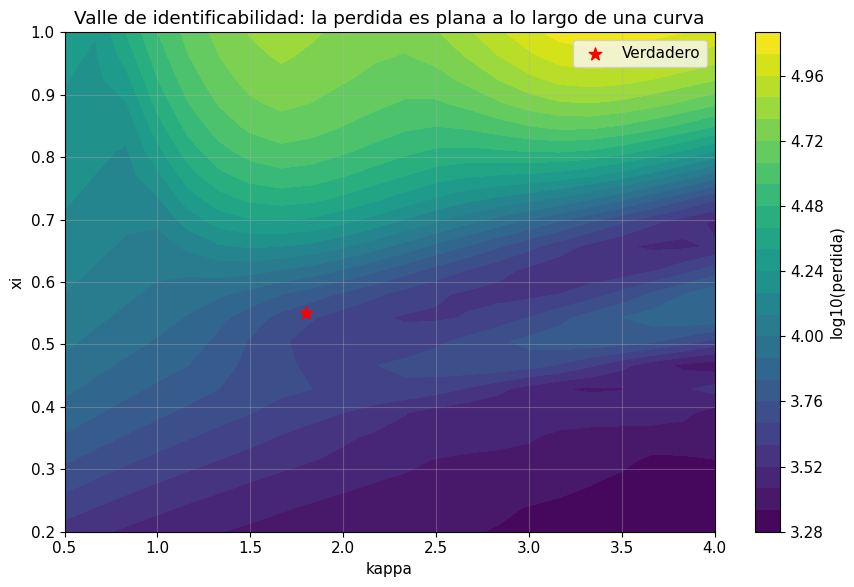

El valle oscuro (perdida baja) es una CURVA, no un punto:
distintos (kappa,xi) sobre ese valle dan casi la misma superficie.


In [6]:
# Barremos kappa y xi alrededor del optimo, reoptimizando el resto seria caro;
# aqui fijamos v0,theta,rho en los verdaderos y vemos el valle en (kappa,xi).
kappas=np.linspace(0.5,4.0,22)
xis   =np.linspace(0.2,1.0,22)
KK,XX=np.meshgrid(kappas,xis)
L=np.zeros_like(KK)
v0f,thf,rhf=true_params[0],true_params[1],true_params[4]
for a in range(KK.shape[0]):
    for b in range(KK.shape[1]):
        L[a,b]=loss((v0f,thf,KK[a,b],XX[a,b],rhf),market,S0,r)

fig,ax=plt.subplots(figsize=(9,6))
cf=ax.contourf(KK,XX,np.log10(L+1e-12),levels=25,cmap='viridis')
fig.colorbar(cf,label='log10(perdida)')
ax.scatter([true_params[2]],[true_params[3]],color='red',s=90,marker='*',
           zorder=5,label='Verdadero')
ax.set_xlabel('kappa'); ax.set_ylabel('xi')
ax.set_title('Valle de identificabilidad: la perdida es plana a lo largo de una curva')
ax.legend()
plt.tight_layout(); plt.show()
print("El valle oscuro (perdida baja) es una CURVA, no un punto:")
print("distintos (kappa,xi) sobre ese valle dan casi la misma superficie.")


## 5. Mitigaciones del problema de identificabilidad

Hay tres remedios prácticos:

- **Regularizar:** añadir una penalización que jale los parámetros hacia los de ayer (estabilidad temporal).
- **Fijar $\kappa$:** algunos escritorios fijan $\kappa$ a una constante sensata y calibran los otros cuatro.
- **Añadir más vencimientos:** la estructura temporal ayuda a separar $\kappa$ de $\xi$.

Demostramos la segunda: fijar $\kappa$ y calibrar cuatro parámetros da un ajuste igual de bueno con parámetros más estables.


In [7]:
boundsk=[(0.005,0.20),(0.005,0.20),(1.9999,2.00),(0.05,1.5),(-0.95,0.5)]
mejor_fit_k = busqueda_global_rapida(boundsk, loss, market, S0, r, n_candidatos=50, n_refinar=10, seed=1)

print(f"Calibracion con kappa fijo = {boundsk[2][0]}:")
print("\nComparacion verdadero vs recuperado:")
print(f"  {'param':8}{'verdadero':>12}{'recuperado':>12}")
for n,tv,rv in zip(nombres,true_params,mejor_fit_k.x):
    print(f"  {n:8}{tv:>12.4f}{rv:>12.4f}")
rmse_precio=np.sqrt(np.mean(np.array(residuals(mejor_fit_k.x))**2))
print(f"\nRMSE en precio: {rmse_precio:.5f}")


Refinando localmente los 10 mejores candidatos del escaneo global...
Fit 1 de 10: costo=54.0945, params=[ 0.04371595  0.10599435  1.99993714  0.67418233 -0.6750461 ]
Fit 2 de 10: costo=68.5052, params=[ 0.04136009  0.09738482  1.99994297  0.48750705 -0.73036552]
Fit 3 de 10: costo=49.0920, params=[ 0.04511975  0.10541473  1.99994095  0.67179972 -0.69225693]
Fit 4 de 10: costo=48.7540, params=[ 0.04565076  0.10527991  1.99992334  0.6709978  -0.69918989]
Fit 5 de 10: costo=69.3130, params=[ 0.04115991  0.09710236  1.9999474   0.48933842 -0.72074178]
Fit 6 de 10: costo=69.5268, params=[ 0.04110788  0.09707715  1.99990005  0.4894964  -0.71949127]
Fit 7 de 10: costo=223.4420, params=[ 0.03620748  0.09571539  1.99991449  0.32660567 -0.84005429]
Fit 8 de 10: costo=48.8830, params=[ 0.04540177  0.10504376  1.99999303  0.67082143 -0.69418532]
Fit 9 de 10: costo=48.8581, params=[ 0.04565633  0.10555338  1.99993924  0.67166491 -0.70074253]
Fit 10 de 10: costo=140.0877, params=[ 0.0398555   0.1023

## 6. Validación del ajuste

Métricas cuantitativas y chequeos cualitativos:
- **RMSE** en puntos de vol implicita.
- **Error máximo** en la superficie.
- **Sensatez económica** de los parámetros ($\rho<0$ para equities, $\kappa$ no absurdo).


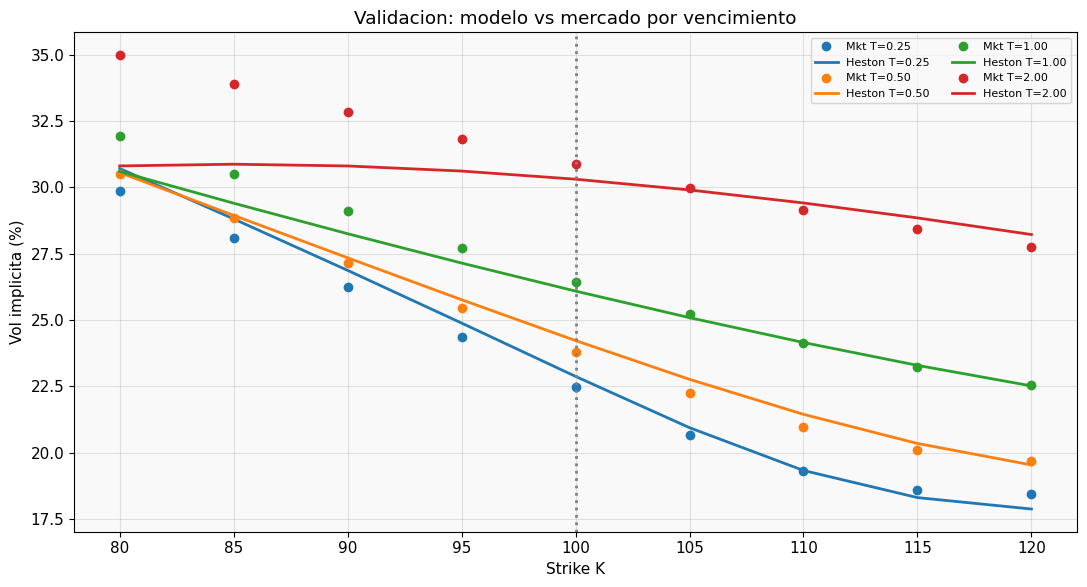

RMSE:        1.0619 puntos de vol
Error maximo:4.1812 puntos de vol
rho<0 (equity-sensible): SI


In [8]:
fig, ax = plt.subplots(figsize=(11,6))
errores=[]
for T in sorted(set(row[1] for row in market)):
    filas=[row for row in market if row[1]==T]
    Ks=np.array([row[0] for row in filas]); orden=np.argsort(Ks); Ks=Ks[orden]
    iv_mkt=np.array([bs_implied_vol(row[2],S0,row[0],r,T)*100 for row in filas])[orden]
    iv_mdl=[]
    for K in Ks:
        pm=heston_call(S0,K,r,T,mejor_fit_k.x[0],mejor_fit_k.x[2],mejor_fit_k.x[1],mejor_fit_k.x[3],mejor_fit_k.x[4])
        iv_mdl.append(bs_implied_vol(pm,S0,K,r,T)*100)
    iv_mdl=np.array(iv_mdl); errores.extend(iv_mdl-iv_mkt)
    l=ax.plot(Ks,iv_mkt,'o',label=f'Mkt T={T:.2f}')[0]
    ax.plot(Ks,iv_mdl,'-',color=l.get_color(),label=f'Heston T={T:.2f}')
ax.axvline(S0,color='gray',ls=':')
ax.set_xlabel('Strike K'); ax.set_ylabel('Vol implicita (%)')
ax.set_title('Validacion: modelo vs mercado por vencimiento'); ax.legend(fontsize=8,ncol=2)
plt.tight_layout(); plt.show()

errores=np.array(errores)
print(f"RMSE:        {np.sqrt(np.mean(errores**2)):.4f} puntos de vol")
print(f"Error maximo:{np.max(np.abs(errores)):.4f} puntos de vol")
print(f"rho<0 (equity-sensible): {'SI' if mejor_fit_k.x[4]<0 else 'NO'}")


## 7. Los límites estructurales de Heston

Aunque la calibración sea perfecta, el modelo tiene limites que ningún ajuste esconde:

- **Skew de corto plazo:** Heston no genera suficiente skew para vencimientos muy cortos (semanas). La difusión continua no basta.
- **Sin saltos:** los mercados reales dan gaps. Los caminos continuos de Heston subvaluan las alas de corto plazo. Extensiones añaden saltos (modelo de **Bates**).
- **Un solo factor:** una sola varianza no captura toda la estructura temporal del skew. Modelos multi-factor o de **volatilidad rugosa** lo abordan.

**Dónde Heston sigue ganando:** vencimientos de mediano a largo plazo, y como benchmark transparente y rápido de calibrar.


## 8. Preguntas y respuestas

### Preguntas de Luis

**P1. ¿Cómo se interpreta el primer gráfico de $\xi$ vs $\kappa$ (celda 11)? ¿Qué es exactamente lo que estamos graficando?**

Es un corte 2D de la superficie de pérdida de 5 dimensiones. Se fijan $v_0$, $\theta$ y $\rho$ en sus valores **verdaderos** (los que generaron la superficie sintética), y se barre una malla de 22×22 combinaciones de $\kappa\in[0.5,4.0]$ y $\xi\in[0.2,1.0]$, evaluando `loss` en cada combinación. Se grafica $\log_{10}(\text{pérdida})$ como `contourf` (escala log porque la pérdida varía en varios órdenes de magnitud), y la estrella roja marca el punto $(\kappa,\xi)=(1.8,0.55)$ verdadero.

Lo que revela el gráfico no es un mínimo puntual (un "hoyo" aislado), sino una **banda oscura alargada y curva** — un valle entero de combinaciones $(\kappa,\xi)$ que producen casi la misma pérdida baja. Esa es la prueba visual del problema de identificabilidad: con los datos de precios disponibles, el modelo no puede distinguir entre esas combinaciones — todas generan casi la misma superficie de precios.

**P2. ¿Por qué fijamos $\kappa$ en 2 (celda 13)?**

La sección 5 propone tres mitigaciones al problema de identificabilidad: regularizar hacia los parámetros de ayer, fijar $\kappa$ a una constante sensata, o agregar más vencimientos. El notebook demuestra la segunda, con `boundsk` restringiendo $\kappa$ a $[1.9999, 2.00]$ — prácticamente fijo en 2.0.

El valor 2.0 se eligió **deliberadamente distinto** del verdadero (1.8), no por descuido: el punto pedagógico es que en la vida real nunca conoces el $\kappa$ verdadero, así que fijarlo al valor exacto sería trampa (solo probaría que "si ya sabes la respuesta, usarla ayuda", algo trivial). Al fijarlo en un valor razonable pero no exacto, se muestra el argumento real a favor de esta mitigación: aun sin conocer $\kappa$ con precisión, fijarlo a una constante plausible (basada en experiencia de escritorio, órdenes de magnitud típicos de reversión a la media en índices) da un ajuste de precios casi igual de bueno (RMSE en precio pasó de 0.75 a 1.16 — algo peor, pero todavía chico), eliminando de paso la ambigüedad del valle para ese parámetro.

**P3. ¿Cómo interpreto el último gráfico (celda 15)?**

Es el mismo tipo de gráfico de validación que en Calibración I (vol implícita de mercado vs. modelo, por vencimiento), pero aquí "mercado" es la superficie **sintética** (verdad conocida), y la curva del modelo usa `mejor_fit_k.x` — los parámetros de la calibración con **$\kappa$ fijo** (sección 5), no la calibración libre de la sección 3.

Debajo del gráfico: RMSE = 1.06 puntos de vol, error máximo = 4.18 puntos, y `rho<0` = SI (sensatez económica: correlación spot-volatilidad negativa, el efecto apalancamiento típico de equities).

La lectura clave: aunque $\theta$ y $\xi$ quedaron notablemente lejos de sus valores verdaderos (celda 13: $\theta=0.105$ vs. verdadero $0.05$; $\xi=0.671$ vs. verdadero $0.55$), y $\kappa$ se fijó deliberadamente en un valor distinto al verdadero, **el modelo sigue reproduciendo la superficie observada casi tan bien como antes**. Ese es el argumento central de toda la sección: un RMSE bajo / un buen ajuste visual **no prueba** que recuperaste los parámetros verdaderos — solo prueba que el modelo reproduce bien los precios. La identificación individual de $(\kappa,\theta,\xi)$ sigue siendo ambigua por el valle plano, incluso cuando el ajuste en precio es excelente.

---

### Profundizando: ¿qué hacen exactamente los chequeos de no-arbitraje?

**Qué estamos haciendo, mecánicamente.** `chequeos_arbitraje(market, S0)` toma `market` y lo agrupa por vencimiento $T$. Para cada $T$, ordena los quotes de ese vencimiento por strike creciente y calcula dos pruebas sobre la función $C(K)$ (precio de call como función del strike, a $T$ fijo):

- **Monotonía:** `np.diff(Cs) <= 1e-9` revisa que cada precio no sea mayor que el anterior — es decir, que $C(K)$ sea no creciente en $K$. El `1e-9` no es arbitrario: es una tolerancia numérica, no económica. Como los precios "de mercado" aquí vienen de integrar a `heston_call` con `quad` (que trunca la integral de Fourier en $u=200$ en vez de $\infty$), hay ruido numérico de punto flotante del orden de $10^{-10}$-$10^{-12}$ en cada precio. Sin esa tolerancia, ese ruido podría hacer que dos precios casi idénticos aparentaran "subir" en vez de "bajar" y disparara una falsa alarma de arbitraje que en realidad es solo error numérico de la cuadratura.

- **Convexidad (mariposa):** `butterfly = Cs[:-2] - 2*Cs[1:-1] + Cs[2:]` es la segunda diferencia discreta de $C(K)$ — el análogo numérico de $\partial^2C/\partial K^2$. Se exige `>= -1e-9` (no negativa, con la misma tolerancia numérica de antes). Ojo con un supuesto escondido: esta fórmula de 3 puntos solo es válida cuando los strikes están **igualmente espaciados**. Aquí funciona porque `strikes = [80,85,90,...,120]` tiene paso constante de 5; con una malla real de strikes irregular (como los strikes que Yahoo Finance realmente ofrece) esta fórmula daría un resultado sesgado y habría que usar una segunda diferencia ponderada por los espaciamientos reales, o revisar convexidad viendo que la pendiente secante $\frac{C(K_{i+1})-C(K_i)}{K_{i+1}-K_i}$ sea no decreciente en $i$.

**Qué buscamos, y por qué importa.** Ambas condiciones son **model-free**: se derivan solo de que no debe existir arbitraje estático, sin asumir Black-Scholes, Heston, ni ningún modelo en particular. Son condiciones necesarias que *cualquier* conjunto racional de precios de opciones europeas debe cumplir.

- Si la monotonía se rompe (un call de strike más alto vale más que uno de strike más bajo), puedes comprar el call barato (strike bajo) y vender el caro (strike alto) por un crédito neto, y el payoff de esa posición combinada nunca es negativo — arbitraje puro, sin importar hacia dónde se mueva el subyacente.

- Si la convexidad se rompe, puedes armar una mariposa (comprar un call en $K-h$, comprar un call en $K+h$, vender dos calls en $K$) por un costo neto negativo, y el payoff de una mariposa siempre es $\geq 0$ — otra vez arbitraje. Pero hay algo más profundo aquí: por la fórmula de Breeden-Litzenberger, la densidad de riesgo-neutral implícita es $q(K) = e^{rT}\frac{\partial^2 C}{\partial K^2}$. Revisar convexidad **es literalmente revisar que esa densidad implícita nunca sea negativa** — y una densidad de probabilidad negativa no tiene sentido bajo ninguna interpretación. La convexidad no es un capricho técnico: es la condición de que "existe una distribución de probabilidad consistente con estos precios".

- El markdown de la sección 2 menciona una **tercera** condición — la estructura de calendario (un vencimiento largo debe valer al menos lo mismo que uno corto, mismo strike) — pero si revisas `chequeos_arbitraje` con cuidado, notarás que el código **no la calcula**: `reporte[T]` solo guarda `monotonia`, `convexidad` y `min_butterfly`. Es una laguna real entre lo que el texto promete y lo que el código hace. Si quisieras cerrarla, agregarías algo así, comparando el mismo strike entre vencimientos consecutivos:

```python
vencimientos = sorted(set(row[1] for row in market))
for i in range(len(vencimientos)-1):
    T1, T2 = vencimientos[i], vencimientos[i+1]
    precios_T1 = {row[0]: row[2] for row in market if row[1]==T1}
    precios_T2 = {row[0]: row[2] for row in market if row[1]==T2}
    strikes_comunes = set(precios_T1) & set(precios_T2)
    calendario_ok = all(precios_T2[K] >= precios_T1[K] - 1e-9 for K in strikes_comunes)
```

**Qué hacer si un chequeo falla (no encontramos lo que buscamos).** Nunca se deja que el optimizador "absorba" la violación — Heston es, por construcción, un modelo libre de arbitraje, así que no existe combinación de $(v_0,\theta,\kappa,\xi,\rho)$ que pueda reproducir exactamente una malla que viola arbitraje. El optimizador simplemente reparte ese error imposible de forma más o menos arbitraria entre los puntos cercanos, y esa distorsión termina contaminando justo los parámetros que ya sabemos que son frágiles ($\kappa,\xi,\theta$, atrapados en el valle plano de la sección 4).

El orden correcto es:

1. **Diagnosticar el origen.** Con datos reales, la mayoría de las violaciones de monotonía/convexidad no son arbitraje genuino sino quotes obsoletos, cruzados (bid > ask por un instante), o de bajísima liquidez. Revisa volumen y spread del punto sospechoso — es probablemente ruido de datos, no una oportunidad de arbitraje real.
2. **Si es ruido de datos: descártalo.** Igual que el filtro de liquidez que ya construimos (volumen cero, spread absurdo), simplemente elimina ese quote de `market` antes de calibrar.
3. **Si la violación persiste en quotes limpios y líquidos:** repara la superficie antes de calibrar, no después. Ajusta una interpolación que garantice monotonía y convexidad (splines monótonos/convexos, o una parametrización como SVI con restricciones explícitas de no-arbitraje) sobre los precios crudos, y calibra Heston contra esa superficie ya corregida.
4. **Lo que nunca se hace:** pasar la malla cruda, con violaciones sin resolver, directo a `busqueda_global_rapida`. El síntoma de haberlo hecho mal no es un error explícito — es un ajuste que converge "bien" en RMSE pero con parámetros económicamente absurdos o inestables de un día a otro, porque el optimizador estuvo compensando una imposibilidad matemática en vez de estimar dinámica real de mercado.

`min_butterfly` en el reporte no es solo informativo por curiosidad: te dice **qué tan grave** es la violación, no solo si existe. Un `min_butterfly` de $-10^{-8}$ es indistinguible de ruido numérico y no amerita acción; un `min_butterfly` de $-2.5$ (en las unidades de precio) es una violación real que hay que resolver antes de calibrar.

### Preguntas de un alumno

**P4. En la calibración libre, $v_0$ y $\rho$ se recuperan casi exactos, pero $\theta$ y $\kappa$ quedan lejísimos — ¿por qué el problema "castiga" tan distinto a cada parámetro si todos entran en el mismo vector de pérdida?**

No es que el optimizador trate a unos parámetros con más cuidado que a otros — es que no todos dejan la misma "huella" en los precios observados. $v_0$ controla el nivel de varianza *ahora mismo*, y domina casi en solitario la vol implícita ATM de muy corto plazo: no hay otro parámetro que pueda sustituir su efecto ahí, así que los quotes cortos lo fijan con precisión. $\rho$ controla la inclinación/asimetría de la sonrisa (el skew): es prácticamente la única palanca que produce esa asimetría específica, así que también queda bien anclado.

$\theta$ y $\kappa$, en cambio, solo entran a través de su efecto **combinado** sobre la trayectoria de la varianza esperada en el tiempo, $E[v_T]=\theta+(v_0-\theta)e^{-\kappa T}$. Con apenas 4 vencimientos muestreados (0.25, 0.5, 1, 2 años), muchas combinaciones $(\theta,\kappa)$ —junto con el $\xi$ correspondiente sobre el valle— reproducen casi la misma trayectoria de varianza en esos 4 puntos, aunque individualmente sean muy distintas de la verdadera. De ahí que el RMSE en precio sea diminuto pese a que $\theta$ y $\kappa$ estén muy lejos de sus valores verdaderos.

**P5. Si en vez de fijar $v_0,\theta,\rho$ en sus valores VERDADEROS al graficar el valle $\kappa$–$\xi$ usáramos los valores RECUPERADOS de la calibración libre, ¿se vería el valle igual, o más ancho?**

El valle en sí (su existencia y su forma aplanada/curva) seguiría apareciendo — es una propiedad estructural del modelo dado el conjunto de vencimientos muestreados, no un accidente de qué punto elijas fijar. Pero la ubicación cambiaría: con $\theta$ fijo en el valor recuperado (0.20, no 0.05), el mínimo de esa nueva rebanada ya no estaría en $(\kappa,\xi)=(1.8,0.55)$ sino cerca de $(0.72, 0.67)$ — el punto que la calibración libre efectivamente encontró, porque es el que minimiza la pérdida *dado ese $\theta$ recuperado*. La estrella roja (el punto verdadero) probablemente ya no caería sobre la banda oscura de esa nueva rebanada, porque estás evaluando con $v_0,\theta,\rho$ "equivocados". En resumen: mismo tipo de valle, pero recentrado — evidencia de que la degeneración es conjunta entre $\theta,\kappa,\xi$, y el gráfico 2D es solo un corte de esa variedad plana en 3D.

**P6. Con un RMSE en precio de 0.75 (libre) o 1.16 (kappa fijo), ¿qué tan "malo" es esto en términos reales, y a partir de qué RMSE deberíamos preocuparnos?**

Ojo con las unidades: el "RMSE en precio" de la celda 9/13 se calcula sobre `residuals(...)`, que ya vienen **ponderados** por $w=1/\text{spread}$ (no es el error crudo en dólares). Con spreads sintéticos del 2% del precio, $w$ ronda 5-10, así que ese RMSE ponderado de 0.75-1.16 corresponde a un error crudo de precio de unos cuantos centavos sobre opciones que valen varios dólares — un error relativo pequeño, no algo alarmante.

La referencia más intuitiva para "qué tan preocuparse" es el RMSE en **puntos de vol implícita** (celda 15), que es la misma métrica que usamos con datos reales de SPY antes en el curso: ahí un ajuste sólido rondó 0.5 puntos, y aquí con $\kappa$ fijo obtuvimos ~1.06. Como regla de dedo: por debajo de 1-2 puntos de vol, el ajuste es razonablemente bueno para uso práctico; arriba de 3-5 puntos, normalmente algo anda mal — datos sin limpiar bien, optimizador que no convergió, o el modelo genuinamente luchando (por ejemplo, con vencimientos muy cortos, ver sección 7).

**P7. El error máximo (4.18 puntos) es casi 4 veces el RMSE (1.06) — ¿en qué strikes/vencimientos ocurre, y es sistemáticamente en las colas o en los vencimientos cortos?**

Por todo lo que hemos visto (tanto en los datos reales de SPY como en la lógica de la sección 7), lo esperable es que el error máximo esté en el vencimiento más corto ($T=0.25$) y/o en los strikes más extremos de la malla ($K=80$ o $K=120$) — ahí es donde la diferencia entre la trayectoria de varianza verdadera y la trayectoria "equivalente pero distinta" que recuperó el calibrador se nota más, antes de que la reversión a la media tenga tiempo de promediar las diferencias.

Pero esto es una expectativa razonada, no una lectura exacta del gráfico — para saberlo con certeza, hay que instrumentar el código: en la celda 15, en vez de solo `errores.extend(iv_mdl-iv_mkt)`, guarda también los `(K,T)` correspondientes (por ejemplo en tuplas), y al final saca el `argmax` del valor absoluto del error para ubicar exactamente el strike y vencimiento responsables, en vez de adivinar por inspección visual.

**P8. De las tres mitigaciones (regularizar, fijar $\kappa$, más vencimientos), ¿por qué el notebook solo implementa "fijar $\kappa$"? ¿Las otras no funcionan tan bien, o es solo la más simple de mostrar?**

Es una cuestión de economía didáctica, no de que las otras mitigaciones sean inferiores. Fijar $\kappa$ es un cambio de una sola línea (apretar `bounds`) que reutiliza exactamente la misma maquinaria (`loss`, `residuals`, `busqueda_global_rapida`) ya construida — cero código nuevo. Regularizar requeriría modificar `loss` para sumar una penalización tipo $\lambda\sum(\Theta-\Theta_{\text{ayer}})^2$, y necesitarías tener a la mano una calibración previa ("de ayer") hacia la cual regularizar, algo que no existe en un ejercicio sintético de un solo corte. Agregar más vencimientos implicaría regenerar toda la malla sintética con otro `mats`, cambiando el experimento entero. En la práctica de escritorio, lo común es combinar las tres — no es que fijar $\kappa$ sea "la mejor", es la más barata de demostrar en una sola celda.

**P9. Se fijó $\kappa$ en 2.0 y no en el verdadero 1.8 (que conocíamos por ser datos sintéticos) — ¿fue deliberado para simular ignorancia real, o hubiera dado mejor ajuste usar 1.8?**

Deliberado, y es justo la respuesta a la pregunta 2 de Luis: usar el valor exacto 1.8 habría probado algo trivial ("si ya sabes la respuesta, usarla ayuda"). El punto de la demostración es mostrar que la mitigación funciona incluso **sin conocer el valor verdadero** — que es la situación real en cualquier escritorio. Sí, es casi seguro que fijar en 1.8 hubiera dado un RMSE ligeramente mejor que fijar en 2.0 (por construcción, está más cerca de lo que generó los datos), pero ese no es el objetivo: el objetivo es mostrar que el ajuste no se degrada mucho aunque el valor fijo esté "un poco mal" — que es la garantía que necesitas para confiar en esta técnica con mercados reales, donde nunca vas a acertarle exacto.

**P10. Los chequeos de no-arbitraje salieron todos "OK" porque la superficie es sintética. En datos reales, si alguno fallara, ¿se descarta ese punto, se corrige antes de calibrar, o se deja que el optimizador lo absorba?**

Se corrige **antes** de calibrar — nunca se deja que el optimizador lo absorba. La advertencia del notebook ("el optimizador pelea contra el arbitraje y aterriza en parámetros distorsionados") existe porque Heston es un modelo libre de arbitraje por construcción: no importa qué parámetros uses, **no puede** reproducir exactamente una malla de precios que viola arbitraje — el optimizador simplemente reparte ese error imposible de forma más o menos arbitraria entre los puntos cercanos, contaminando la forma de la sonrisa que recuperas y sesgando $\kappa,\xi,\rho$ por razones que no tienen nada que ver con la dinámica real del mercado.

En la práctica: primero diagnostica el origen (muchas violaciones en datos reales son quotes obsoletos o cruzados, no arbitraje genuino — en ese caso simplemente descarta ese quote, igual que el filtro de liquidez que ya construimos). Si la violación persiste incluso en quotes líquidos y confiables, se suaviza la superficie con una interpolación libre de arbitraje (splines monótonos/convexos, o una parametrización tipo SVI con restricciones de no-arbitraje) antes de calibrar Heston sobre la superficie ya corregida.

**P11. La función de pérdida pondera por $1/\text{spread}^2$ — ¿esa ponderación agrava o alivia el problema de identificabilidad $\kappa$–$\xi$? ¿Spreads sintéticos más angostos habrían ayudado?**

No, y esta es una distinción importante: el peso $1/\text{spread}^2$ es un remedio para el **ruido de medición** de cada quote (cuánto confiar en un precio observado), no para la identificabilidad **estructural** del modelo. En la celda 4, el spread solo se usa para ponderar la pérdida — los precios sintéticos en sí son precios exactos de Heston con los parámetros verdaderos, sin ruido añadido. El valle $\kappa$–$\xi$ de la celda 11 aparece incluso con una superficie perfectamente limpia, porque nace de la estructura matemática de Heston: varias combinaciones $(\kappa,\xi,\theta)$ generan la *misma* trayectoria de varianza en los 4 vencimientos muestreados. Estrechar o ensanchar el spread sintético no cambia esa geometría — solo cambiaría cuánto "confías" en cada precio si hubiera ruido real de por medio.

Lo que sí ataca la causa raíz es la tercera mitigación de la sección 5: agregar más vencimientos. El trabajo de $\kappa$ es describir *qué tan rápido* decae la varianza en el tiempo — para fijar una tasa de decaimiento necesitas suficientes puntos distintos en el tiempo, no precios más "confiables" en los puntos que ya tienes.